# This notebook walks through stochastic extracellular stimulation

In [43]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import helperFuncs as hf

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [44]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Build a cell, point to the params file of interest 

In [45]:
# Code to setup a single simulated RGC
# Default params file located at: 'cell_param_files/params_35.csv'
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')

### Output simple facts: (x,y,z) of soma center and all compartments 

In [46]:
# print out where the center of the soma is located and shift if needed
#  Note, behind the scenes this is shifting all simualted compartments by 
#  the necessary x,y,z transforms to get the cell to the right spot 
print('Current soma center is located at: ', RGC.soma_center) # units: [um]

degrees = 70
radians = np.deg2rad(degrees)

RGC._rotateZ(radians)
print('New soma center is located at: ', RGC.soma_center)

RGC.shift_cell_x_y_z(80,-20,0)
print('New soma center is located at: ', RGC.soma_center)

Current soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [-11.9399995803833, 0.0, 10.0]
New soma center is located at:  [87.85627746582031, -31.219928741455078, 0.0]


In [47]:
# Code to traverse through all sections and segments of a cell. This is very
#  useful for debugging and probing different features (membrane voltage, 
#  currents, channel dynamics) at each segment. It also helps to understand 
#  how the cell is layed out in space. 
for sec in RGC.section_list: 
    for seg in sec:
        print(seg)
        print('Segment coordinates: ', seg.x_xtra, seg.y_xtra, seg.z_xtra)

Cell[1].soma(0.1)
Segment coordinates:  87.85627746582031 -31.21992874145508 -8.0
Cell[1].soma(0.3)
Segment coordinates:  87.85627746582031 -31.219928741455078 -3.999999999999999
Cell[1].soma(0.5)
Segment coordinates:  87.85627746582031 -31.219928741455078 2.220446049250313e-15
Cell[1].soma(0.7)
Segment coordinates:  87.85627746582031 -31.219928741455078 4.000000000000002
Cell[1].soma(0.9)
Segment coordinates:  87.85627746582031 -31.219928741455078 8.0
Cell[1].dend[0](0.125)
Segment coordinates:  86.59435302177843 -21.986817307246735 -4.969561009410709
Cell[1].dend[0](0.375)
Segment coordinates:  81.60271543740558 -22.28839381627145 -10.908683028232128
Cell[1].dend[0](0.625)
Segment coordinates:  76.47404140663618 -22.68266395925147 -16.601027291926613
Cell[1].dend[0](0.875)
Segment coordinates:  69.51691571870995 -24.930059511554045 -17.39469844351447
Cell[1].dend[50](0.5)
Segment coordinates:  67.7329216003418 -29.157984733581543 -17.5
Cell[1].dend[52](0.25)
Segment coordinates:  69.

In [48]:
# Code to traverse through all sections and segments of a cell. This is very
#  useful for debugging and probing different features (membrane voltage, 
#  currents, channel dynamics) at each segment. It also helps to understand 
#  how the cell is layed out in space. 
for sec in RGC.section_list: 
    for seg in sec:
        print(seg)
        print('Segment coordinates: ', seg.x_xtra, seg.y_xtra, seg.z_xtra)

Cell[1].soma(0.1)
Segment coordinates:  87.85627746582031 -31.21992874145508 -8.0
Cell[1].soma(0.3)
Segment coordinates:  87.85627746582031 -31.219928741455078 -3.999999999999999
Cell[1].soma(0.5)
Segment coordinates:  87.85627746582031 -31.219928741455078 2.220446049250313e-15
Cell[1].soma(0.7)
Segment coordinates:  87.85627746582031 -31.219928741455078 4.000000000000002
Cell[1].soma(0.9)
Segment coordinates:  87.85627746582031 -31.219928741455078 8.0
Cell[1].dend[0](0.125)
Segment coordinates:  86.59435302177843 -21.986817307246735 -4.969561009410709
Cell[1].dend[0](0.375)
Segment coordinates:  81.60271543740558 -22.28839381627145 -10.908683028232128
Cell[1].dend[0](0.625)
Segment coordinates:  76.47404140663618 -22.68266395925147 -16.601027291926613
Cell[1].dend[0](0.875)
Segment coordinates:  69.51691571870995 -24.930059511554045 -17.39469844351447
Cell[1].dend[50](0.5)
Segment coordinates:  67.7329216003418 -29.157984733581543 -17.5
Cell[1].dend[52](0.25)
Segment coordinates:  69.

## Step 2: Setup electrical stimulus 

In [62]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms] # Prev, .005
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 30 # units: [ms]
Stim['amp'] = [-0.52] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[60,-90,45]] 
Stim['electrode_type'] = 'disk' # OLD: 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3] #[2/3,-1,1/3] 
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

# define transfer impedances 
active_x = [] # Artifact of old code, set as empty
hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)

## Step 3: Set up recording vectors in order to probe what happened 

### Current recording vectors at all segment compartments

In [63]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for section in RGC.section_list:
    iOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        iOut[section.name()]['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [64]:
vOut = {}
for section in RGC.section_list:
    vOut[section.name()] = {}
    for seg, i in zip(section,range(section.nseg)):
        vOut[section.name()]['vmem' + str(i)] = h.Vector().record(seg._ref_v)

### Time vector

In [65]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

### Determine threshold 

In [66]:
thr_c, t_vec, vRec_cathodic = hf.lowerThreshold_v2(Stim, RGC, lower=0, upper=5, num=25, epsilon=0.02)

Testing current:  [-0.0]
Testing current:  [-0.15535269687227293]
Testing current:  [-0.33483985417003437]
Testing current:  [-0.5422108254079407]
Testing current:  [-0.7817974362806785]
Testing current:  [-1.0586044732869841]
Starting trial with 0.9202009547838313 upper bound = 1.0586044732869841 lower bound = 0.7817974362806785
Starting trial with 0.8509991955322549 upper bound = 0.9202009547838313 lower bound = 0.7817974362806785
Starting trial with 0.8163983159064667 upper bound = 0.8509991955322549 lower bound = 0.7817974362806785
Starting trial with 0.7990978760935726 upper bound = 0.8163983159064667 lower bound = 0.7817974362806785
Lower threshold found at:  0.8163983159064667  uA


## Step 4: Inject noise in ion channels

In [70]:
### --- inject Gaussian noise into axon
tstop = 80
dt = 0.005
current = 0.81
random_stream_offset_ = (tstop+1000)*1/dt * np.floor(current*(1e-3)*10)
r = h.Random()
trials = 10
knoise = 0.00035*(1e3)
spikes = 0
for k in range(trials):
    ## --- Inject noise into all compartments
    for sec_name in RGC.section_list:
        objs = [h.InGauss(seg.x,sec=sec_name) for seg in sec_name]
        for obj in objs:
            r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
            segment = obj.get_segment()

            obj.delay = 0
            obj.dur = tstop
            obj.mean = 0
            # TODO: change whether axonal or somatic
            obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
                            * segment.gnabar_mammalian_spike_35*1e3))
            obj.noiseFromRandom(r)

            # print('axon noise std: ', obj.stdev)
            
        h.setpointers()


    # ## --- Inject noise into distal axon
    # objs = [h.InGauss(seg.x,sec=RGC.axon) for seg in RGC.axon]
    # for obj in objs:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     * segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)

    #     # print('axon noise std: ', obj.stdev)
        
    # h.setpointers()

    # ## --- Inject noise into sodium channel band
    # objs_socb = [h.InGauss(seg.x,sec=RGC.SOCB) for seg in RGC.SOCB]
    # for obj in objs_socb:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     *segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)

    #     # print('socb noise std: ', obj.stdev)

    # h.setpointers()

    # objs_ah = [h.InGauss(seg.x,sec=RGC.AH) for seg in RGC.AH]
    # for obj in objs_ah:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     * segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)
    
    #     # print('ah std: ', obj.stdev)
        
    # h.setpointers()

    # objs_soma = [h.InGauss(seg.x,sec=RGC.cell.soma) for seg in RGC.cell.soma]
    # for obj in objs_soma:
    #     r.MCellRan4(random_stream_offset_*k) #TODO: change back to +k
    #     segment = obj.get_segment()

    #     obj.delay = 0
    #     obj.dur = tstop
    #     obj.mean = 0
    #     # TODO: change whether axonal or somatic
    #     obj.stdev = knoise*(np.sqrt(segment.area()*1e-8*1 \
    #                     * segment.gnabar_mammalian_spike_35*1e3))
    #     obj.noiseFromRandom(r)

    #     # print('soma std: ', obj.stdev)
        
    # h.setpointers()

    ## -- set up recording vectors
    APC_axon = h.APCount(1, sec = RGC.axon)
    APC_axon.thresh = 0 

    vRec_axon = []
    for seg in RGC.axon:
        vRec_axon.append(h.Vector().record(RGC.axon(seg.x)._ref_v))

    ## -- run simulation
    # Stim['amp'] = Stim['polarity']*float(current)
    # tsvec, isvec = hf.setupStimulus(Stim)
    tsvec, isvec = hf.setupStimulus_unit(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)

    ## -- if spike, increment spike count
    if APC_axon.n > 0:
        spike_timing = APC_axon.time
        if spike_timing > 50 and spike_timing < 70:
            spikes += 1
            print('SPIKE: Current: ', current, 'uA, Spikes: ', spikes, '/', k+1)
        else:
            print('SPIKE TIME NOT MET: Current: ', current, 'uA, Spikes: ', spikes, '/', k+1)
            continue
    else:
        print('NO SPIKE: Current: ', current, 'uA, Spikes: ', spikes, '/', k+1)

NO SPIKE: Current:  0.81 uA, Spikes:  0 / 1
NO SPIKE: Current:  0.81 uA, Spikes:  0 / 2
NO SPIKE: Current:  0.81 uA, Spikes:  0 / 3
NO SPIKE: Current:  0.81 uA, Spikes:  0 / 4
NO SPIKE: Current:  0.81 uA, Spikes:  0 / 5
NO SPIKE: Current:  0.81 uA, Spikes:  0 / 6
NO SPIKE: Current:  0.81 uA, Spikes:  0 / 7
SPIKE: Current:  0.81 uA, Spikes:  1 / 8
SPIKE: Current:  0.81 uA, Spikes:  2 / 9
NO SPIKE: Current:  0.81 uA, Spikes:  2 / 10


## Step 5: Visualize what happened

### Plot voltage trace at every compartment and segment 

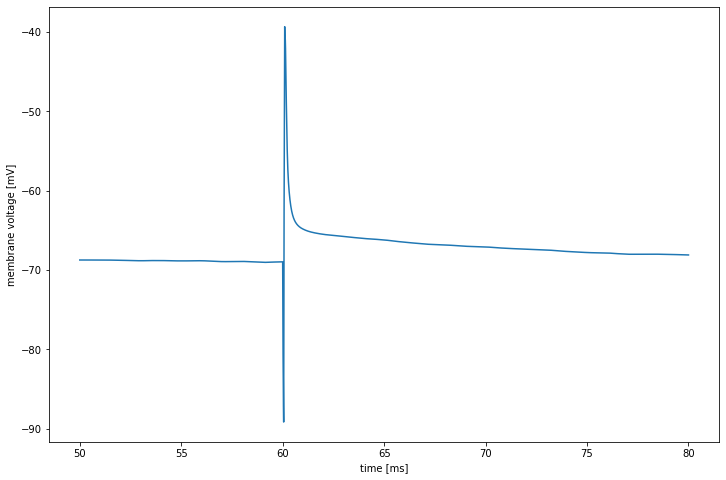

In [25]:
# First, plot just a single axonal voltage trace
v_vec = np.array(vOut['Cell[0].SOCB']['vmem5'])
t_vec = np.array(t)

fig,ax = plt.subplots(1,1,figsize=(12,8))
ax.set_xlabel('time [ms]')
ax.set_ylabel('membrane voltage [mV]')
ax.plot(t_vec[Stim['initDur']:],v_vec[Stim['initDur']:])
  

### Extracellular recording as observed from a given recording electrode (point source approx)

In [ ]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-600,0,35]

# setup vector where to store extracellular voltage profile
if stim_type == 'clamp':
    timeStepsRec = int(h.tstop/h.dt)+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))
elif stim_type == 'extra':
    timeStepsRec = int(Stim['stop']/Stim['dt'])+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Compute distance from electrode to center of each segment [um]
        dist = np.sqrt((seg.xtra.x-recElec[0])**2 + (seg.xtra.y-recElec[1])**2 \
                       + (seg.xtra.z-recElec[2])**2)
        
        # Set transfer impedance for each segment [MOhm]
        tf = Stim['rhoExt'] / (4.0*np.pi*dist*(1e-4)) * 1e-6

        # recOut units: 1e3*MOhm*nA == uV
        if stim_type == 'clamp':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy())
        elif stim_type == 'extra':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

In [ ]:
# Plot extracellular voltaged recorded on recElec
if stim_type == 'clamp':
    plt.plot(np.arange(0,h.tstop+h.dt,h.dt),recOut)
    # do some adaptive peak finding to zoom in on spike
    peak_time = t[recOut.argmin()]
    plt.xlim(0,peak_time+2)
elif stim_type == 'extra':
    plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
    plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')

### Now try with disk electrode approximations

In [ ]:
# Recording electrode position (default is the stimulating electrode)
# recElec = Stim['electrodes'][0]
recElec = [-200,0,45]

# setup vector where to store extracellular voltage profile
if stim_type == 'clamp':
    timeStepsRec = int(h.tstop/h.dt)+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))
elif stim_type == 'extra':
    timeStepsRec = int(Stim['stop']/Stim['dt'])+1
    dtFac = 1
    recOut = np.zeros((timeStepsRec))

print(recOut)


# Setup transfer impedance between recording electrode and cell, then 
#  scale recorded membrane currents to get extracellular voltage profile 
for section in RGC.section_list:
    # print(section.name())
    # Loop over all segments in section
    for seg, k in zip(section,range(section.nseg)):
        # Distance from electrode to center of each segment [cm]
        r = 1e-4*\
            np.sqrt((seg.xtra.x - (recElec[0]))**2\
                    + (seg.xtra.y - (recElec[1]))**2)
        # Vertical distance [cm]
        z = 1e-4*(seg.xtra.z-recElec[2])

        # Transfer impedance [MOhm]  
        rDisk = 1e-4*Stim['elecDiam']/2             
        tf = 1e-6*(2.0*Stim['rhoExt'])/(4.0*np.pi*rDisk) \
            * np.arcsin((2*rDisk) / \
            (np.sqrt((r-rDisk)**2+z**2)+np.sqrt((r+rDisk)**2+z**2)))
                    
        # recOut units: 1e3*MOhm*nA == uV
        if stim_type == 'clamp':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy())
        elif stim_type == 'extra':
            recOut += 1e3 * tf * \
                (iOut[section.name()]['imem' + str(k)].as_numpy()[int(Stim['initDur']/Stim['initDt'])::dtFac])

In [ ]:
# Plot extracellular voltaged recorded on recElec
if stim_type == 'clamp':
    plt.plot(np.arange(0,h.tstop+h.dt,h.dt),recOut)
    # do some adaptive peak finding to zoom in on spike
    peak_time = t[recOut.argmin()]
    plt.xlim(0,peak_time+2)
elif stim_type == 'extra':
    plt.plot(np.arange(0,Stim['stop']+Stim['dt'],Stim['dt']),recOut)
    plt.xlim(9.5,15)

plt.xlabel('Time [ms]')
plt.ylabel('Extracellular voltage [uV]')